# Bitcoin Market Sentiment vs Hyperliquid Trader Performance

## Objective

The objective of this project is to analyze how Bitcoin market sentiment, measured using the Fear & Greed Index, influences trader performance and behavior on Hyperliquid.

Specifically, this analysis investigates:

- Profitability across sentiment regimes
- Win rates across sentiment regimes
- Trading behavior (Buy/Sell decisions)
- Positioning behavior (Long/Short activity)
- Position sizing patterns

The goal is to identify whether market sentiment provides meaningful insights into trader performance.

## 1. Import Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('charts', exist_ok=True)

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## 2. Load Datasets

In [11]:
trades = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

## 3. Initial Data Inspection

We begin by examining dataset dimensions and reviewing sample records.

In [14]:
print(trades.shape)
print(fear.shape)
trades.head()
fear.head()

(211224, 16)
(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


The following inspection confirms column names, data types, and overall dataset quality.

In [15]:
trades.columns
trades.info()
fear.columns
fear.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

## 4. Data Cleaning

The Hyperliquid dataset contains timestamps in DD-MM-YYYY HH:MM format.

To ensure accurate parsing, timestamps are converted using an explicit datetime format before extracting trading dates.

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'],format='%d-%m-%Y %H:%M')

## 5. Data Preparation

Trading timestamps are converted into daily granularity so that they can be merged with the daily Fear & Greed Index observations.

In [35]:
trades['date'] = trades['Timestamp IST'].dt.normalize()
fear['date'] = pd.to_datetime(fear['date'])

The date ranges of both datasets are verified to ensure sufficient overlap before merging.

In [36]:
print("Trades:")
print(trades['date'].min())
print(trades['date'].max())

print()

print("Fear:")
print(fear['date'].min())
print(fear['date'].max())

Trades:
2023-05-01 00:00:00
2025-05-01 00:00:00

Fear:
2018-02-01 00:00:00
2025-05-02 00:00:00


## 6. Dataset Merge

The trading dataset is merged with the Fear & Greed Index using the daily date field.

In [ ]:
merged = trades.merge(fear,on='date',how='left')

merged['classification'].isna().sum()

np.int64(6)

Only a small number of unmatched observations were found and removed prior to analysis.

In [39]:
merged = merged.dropna(subset=['classification'])

## 7. Exploratory Data Analysis

### Profitability by Market Sentiment

We first examine whether average trader profitability changes across different sentiment regimes.

In [40]:
sentiment_pnl = (merged.groupby('classification')['Closed PnL'].agg(['count', 'mean', 'median', 'sum']).round(2))

sentiment_pnl

,count,mean,median,sum
classification,,,,
Extreme Fear,21400,34.54,0.0,739110.25
Extreme Greed,39992,67.89,0.0,2715171.31
Fear,61837,54.29,0.0,3357155.44
Greed,50303,42.74,0.0,2150129.27
Neutral,37686,34.31,0.0,1292920.68


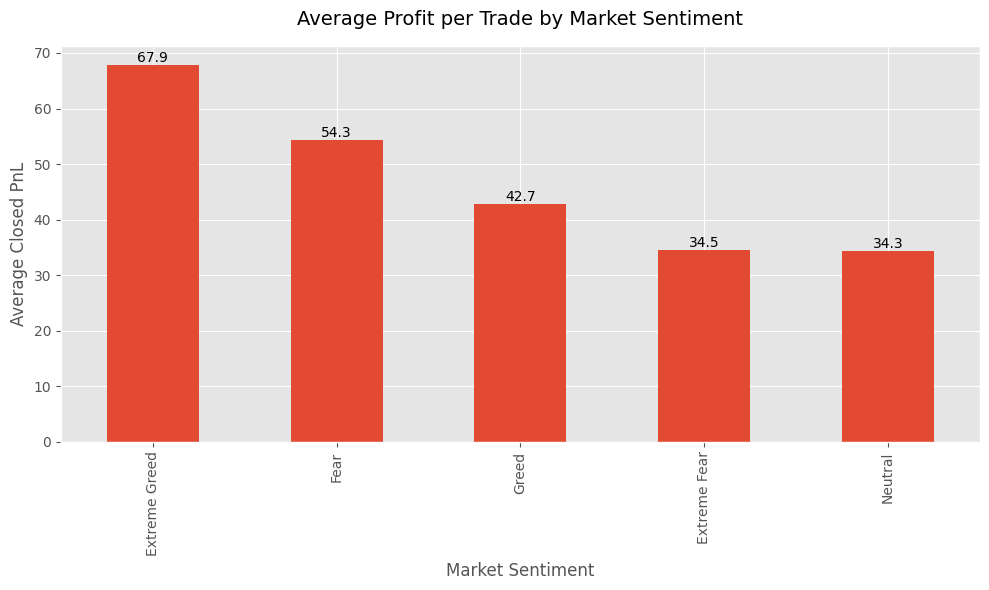

In [50]:
plt.figure(figsize=(10,6))

ax = sentiment_pnl['mean'].sort_values(
    ascending=False
).plot(kind='bar')

plt.title(
    'Average Profit per Trade by Market Sentiment',
    fontsize=14,
    pad=15
)

plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.tight_layout()

plt.savefig(
    'charts/avg_pnl_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interpretation

Extreme Greed generated the highest average profitability.

Interestingly, Fear conditions outperformed Greed conditions, suggesting that fearful markets may provide attractive trading opportunities due to increased volatility and market overreactions.

### Win Rate Analysis

Next, we investigate whether trader success rates vary across sentiment conditions.

In [51]:
merged['win_trade'] = merged['Closed PnL'] > 0

win_rate = (
    merged.groupby('classification')['win_trade'].mean()*100
).round(2)

win_rate.sort_values(ascending=False)

classification
Extreme Greed    46.49
Fear             42.08
Neutral          39.70
Greed            38.48
Extreme Fear     37.06
Name: win_trade, dtype: float64

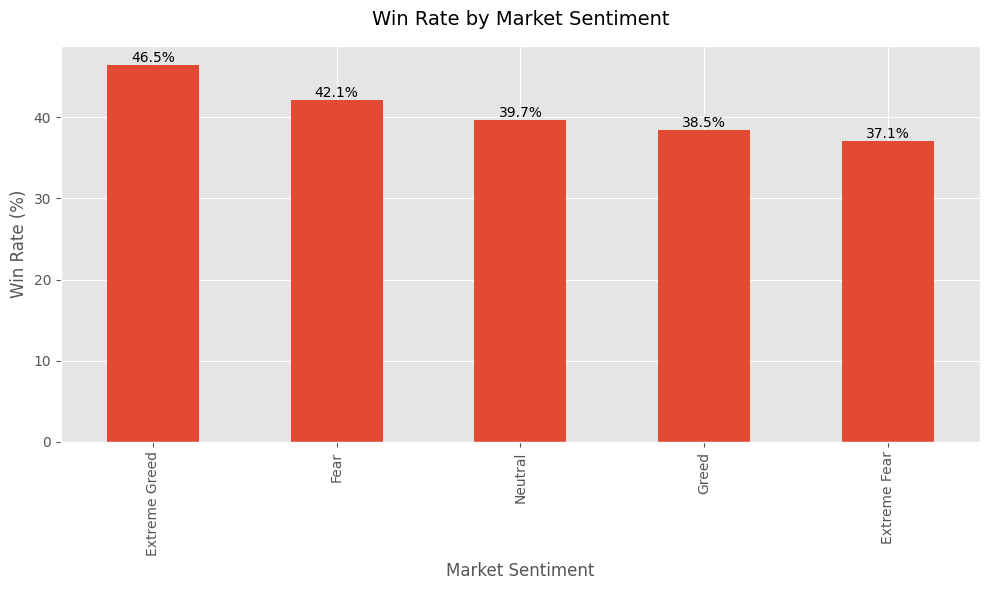

In [53]:
plt.figure(figsize=(10,6))

ax = win_rate.sort_values(
    ascending=False
).plot(kind='bar')

plt.title(
    'Win Rate by Market Sentiment',
    fontsize=14,
    pad=15
)

plt.ylabel('Win Rate (%)')
plt.xlabel('Market Sentiment')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()

plt.savefig(
    'charts/win_rate_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interpretation

Although all sentiment regimes show win rates below 50%, traders remain profitable overall.

This suggests profitability is driven by favorable risk-reward ratios rather than consistently predicting market direction correctly.

### Buy vs Sell Behavior

To understand trader behavior, we compare Buy and Sell activity across sentiment regimes.

In [56]:
side_stats = pd.crosstab(
    merged['classification'],
    merged['Side'],
    normalize='index'
) * 100

side_stats.round(2)

Side,BUY,SELL
classification,,
Extreme Fear,51.10,48.90
Extreme Greed,44.86,55.14
Fear,48.95,51.05
Greed,48.86,51.14
Neutral,50.33,49.67


### Interpretation

More buying activity occurs during Extreme Fear, while selling activity increases during Extreme Greed.

This behavior is consistent with a contrarian trading approach.

### Position Direction Analysis

Direction data provides deeper insight into trader positioning decisions.

In [57]:
direction_stats = pd.crosstab(
    merged['classification'],
    merged['Direction'],
    normalize='index'
) * 100

direction_stats.round(2)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0.00,3.77,29.16,14.57,0.0,0.02,32.73,14.83,4.87,0.0,0.03,0.01
Extreme Greed,0.00,12.83,17.97,16.25,0.0,0.02,15.75,19.16,17.91,0.0,0.03,0.08
Fear,0.00,5.19,27.91,14.91,0.0,0.02,28.82,17.61,5.44,0.0,0.03,0.07
Greed,0.02,9.31,15.90,22.51,0.0,0.03,16.99,23.19,11.90,0.0,0.05,0.11
Neutral,0.00,7.66,26.52,15.52,0.0,0.04,27.12,16.86,6.23,0.0,0.03,0.03


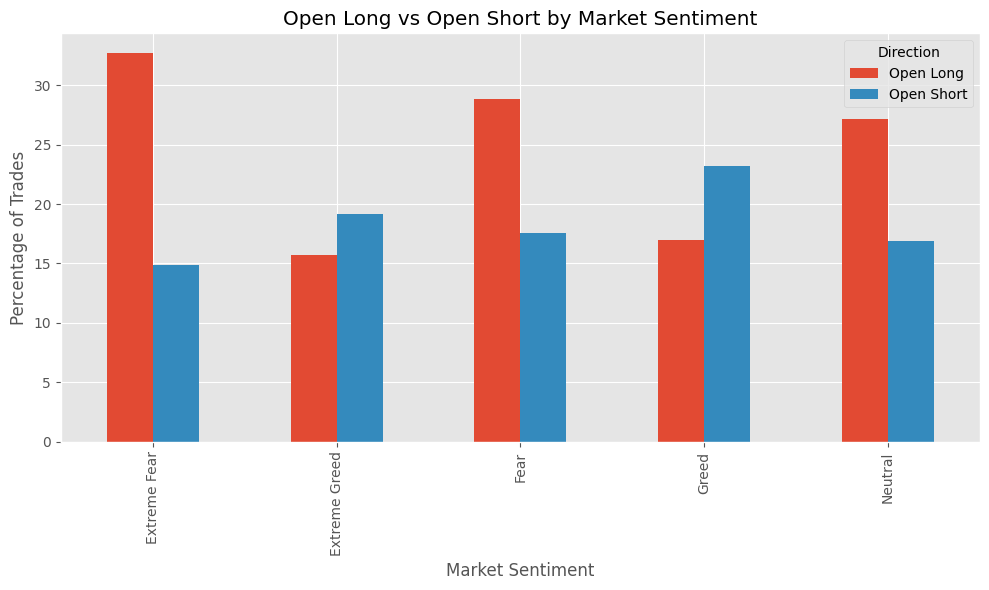

In [60]:
direction_stats[['Open Long','Open Short']]\
    .plot(
        kind='bar',
        figsize=(10,6)
    )

plt.title(
    'Open Long vs Open Short by Market Sentiment'
)

plt.ylabel('Percentage of Trades')
plt.xlabel('Market Sentiment')

plt.tight_layout()

plt.savefig(
    'charts/direction_distribution_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

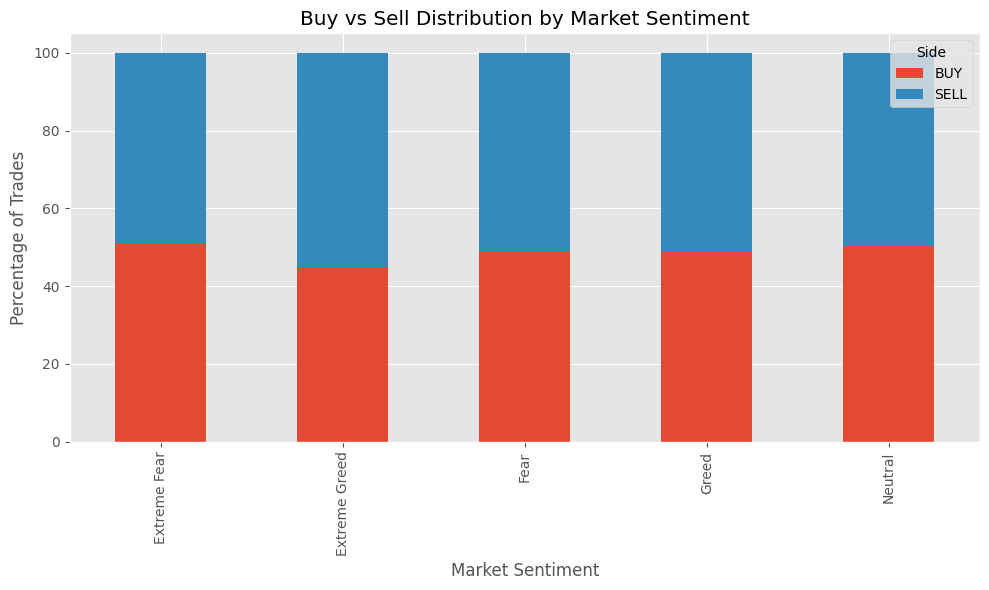

In [58]:
side_stats.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Buy vs Sell Distribution by Market Sentiment')
plt.ylabel('Percentage of Trades')
plt.xlabel('Market Sentiment')

plt.legend(title='Side')
plt.tight_layout()

plt.savefig(
    'charts/side_distribution_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interpretation

Open Long activity is highest during fearful conditions, while Open Short activity increases substantially during Greed regimes.

This provides additional evidence that traders often position against prevailing market sentiment.

In [59]:
merged.groupby('classification')['Size USD'].mean().round(2)

classification
Extreme Fear     5349.73
Extreme Greed    3112.25
Fear             7816.11
Greed            5736.88
Neutral          4782.73
Name: Size USD, dtype: float64

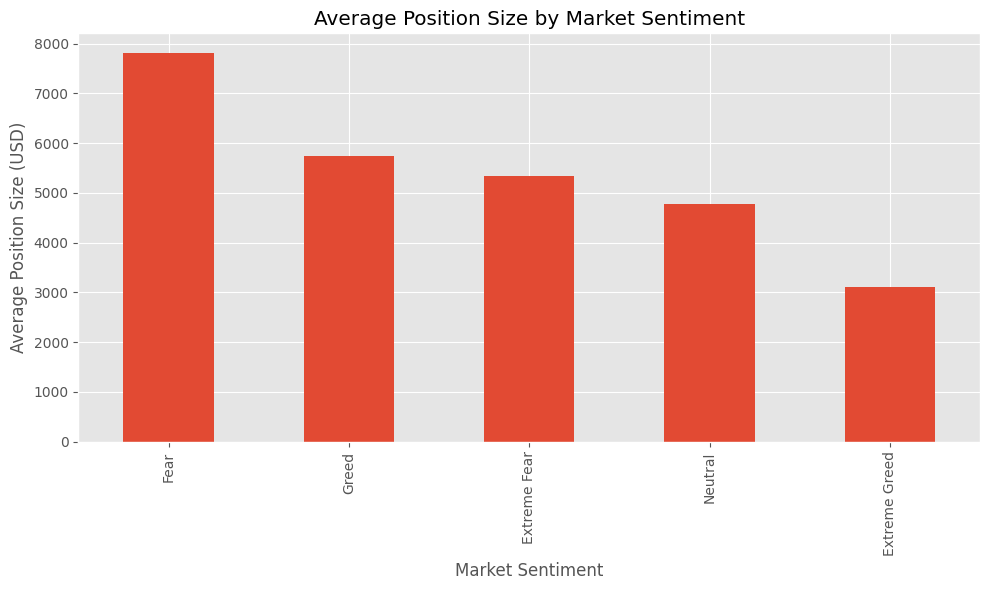

In [61]:
position_size = merged.groupby(
    'classification'
)['Size USD'].mean().round(2)

position_size.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Average Position Size by Market Sentiment'
)

plt.ylabel('Average Position Size (USD)')
plt.xlabel('Market Sentiment')

plt.tight_layout()

plt.savefig(
    'charts/avg_position_size_by_sentiment.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Interpretation

Fear conditions exhibit the largest average position sizes, while Extreme Greed shows the smallest.

Since Extreme Greed still achieves the highest profitability, position size alone does not explain performance differences.

## Key Findings

### 1. Extreme Greed Produced the Highest Profitability

Extreme Greed periods generated the strongest trading performance.

- Average PnL: 67.89
- Win Rate: 46.49%

This suggests traders benefited from strong market momentum and elevated volatility during euphoric market conditions.

---

### 2. Fear Outperformed Greed

Contrary to expectations, Fear conditions outperformed Greed conditions.

| Metric | Fear | Greed |
|----------|----------|----------|
| Average PnL | 54.29 | 42.74 |
| Win Rate | 42.08% | 38.48% |
| Avg Position Size | 7816 | 5737 |

This may indicate that fearful markets provide more attractive trading opportunities due to increased volatility and market overreactions.

---

### 3. Profitability Does Not Require High Accuracy

Win rates remained below 50% across all sentiment regimes.

Despite this:

- Average profitability remained positive.
- Total PnL remained strongly positive.

This suggests traders rely on favorable risk-reward structures rather than consistently predicting market direction correctly.

---

### 4. Evidence of Contrarian Trading

Traders appeared to trade against prevailing sentiment.

Examples:

- More BUY activity during Extreme Fear.
- More SELL activity during Extreme Greed.
- Higher Open Long activity during Fear.
- Higher Open Short activity during Greed.

This indicates traders may exploit emotional market extremes rather than follow crowd behavior.

---

### 5. Position Size Alone Does Not Explain Performance

Fear conditions had the largest average position sizes.

However:

- Extreme Greed produced the highest profitability.
- Extreme Greed had the smallest average position sizes.

This suggests market conditions and trade quality may play a larger role than risk exposure alone.

## Recommendations

Based on the analysis, the following recommendations are proposed:

### 1. Monitor Sentiment as a Trading Signal

Bitcoin Fear & Greed sentiment appears to contain information about future trading performance and trader behavior.

Sentiment indicators should be incorporated alongside technical and market structure signals.

---

### 2. Investigate Fear-Based Market Opportunities

Fear regimes demonstrated:

- Higher profitability than Greed
- Higher win rates
- Larger position sizing

Further research should explore whether volatility during fearful periods creates repeatable trading opportunities.

---

### 3. Focus on Risk-Reward Rather Than Win Rate

Since profitability remained positive despite sub-50% win rates, traders should prioritize:

- Larger average winners
- Controlled downside risk
- Consistent risk management

rather than maximizing trade accuracy.

---

### 4. Study Contrarian Positioning Strategies

The observed increase in long exposure during fear and short exposure during greed suggests that contrarian positioning may contribute to profitability.

Future analysis could test whether systematic contrarian strategies outperform sentiment-following strategies.

---

### 5. Expand Analysis with Additional Features

Future work could include:

- Daily BTC returns
- Market volatility measures
- Trade holding periods
- Account-level performance metrics

to better understand the drivers of profitability.

## Conclusion

This analysis explored how Bitcoin market sentiment relates to Hyperliquid trader behavior and performance.

The results show that sentiment regimes influence profitability, position sizing, and trade direction decisions. Traders demonstrated strong contrarian tendencies, particularly during periods of extreme market emotion.

While Extreme Greed produced the highest profitability, Fear conditions also generated strong performance, suggesting that emotional market environments may create exploitable opportunities.

Overall, the findings indicate that market sentiment provides valuable context for understanding trader behavior and may serve as a useful feature for future predictive trading models.